<a href="https://colab.research.google.com/github/vikassinngh123/AI-ML-Learning/blob/main/Machine-Learning/US_Stock_Returns_kaggel_comp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

!kaggle competitions download -c predict-1-year-us-stock-returns-from-fundamentals

!mkdir dataset

!unzip -q predict-1-year-us-stock-returns-from-fundamentals.zip -d dataset/

!ls dataset

100% 2.44M/2.44M [00:00<00:00, 189MB/s]

sample_submission.csv  test.csv  train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#-------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer , KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
#------------------------------------------------------------------
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
#------------------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
#-------------------------------------------------------------------
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
#-------------------------------------------------------------------
from sklearn.ensemble import VotingRegressor, StackingRegressor

In [3]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.1 MB/s eta 0:00:00


In [4]:
train=pd.read_csv('dataset/train.csv')
test=pd.read_csv('dataset/test.csv')

In [5]:
train.head(5)

,id,ticker,start_year,period_start,period_end,return_pct,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,...,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
0,0,AAPL,2022,2022-03-26,2023-04-01,-5.62,25.28,38.23,6.68,1.95,...,5.460000e+09,0.93,0.88,3.07,0.57,1.473400e+10,1.468700e+10,1.620757e+10,1.640332e+10,0.0
1,1,AAPL,2022,2022-06-25,2023-07-01,36.93,20.97,35.95,5.39,2.37,...,5.433000e+09,0.86,0.82,3.26,0.71,1.477800e+10,1.473400e+10,1.609538e+10,1.626220e+10,0.0
2,2,AAPL,2022,2022-09-24,2023-09-30,13.81,22.23,43.78,5.63,2.32,...,4.946000e+09,0.88,0.85,3.91,0.67,1.484100e+10,1.479300e+10,1.594342e+10,1.632582e+10,0.0
3,3,AAPL,2022,2022-12-31,2023-12-30,48.18,20.13,33.78,4.94,2.22,...,6.820000e+09,0.94,0.89,3.51,0.78,1.487700e+10,1.484000e+10,1.584241e+10,1.595572e+10,0.0
4,4,AAPL,2021,2021-03-27,2022-03-26,44.15,23.43,25.84,5.49,1.35,...,5.219000e+09,1.14,1.09,3.14,0.80,1.422700e+10,1.421200e+10,1.668630e+10,1.692916e+10,0.0


In [6]:
test.head(5)

,id,ticker,start_year,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,gross_margin,operating_margin,net_margin,...,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
0,0,stock_0820,2024,NaN,NaN,NaN,NaN,38.62,-122.73,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.546700e+07,0.0
1,1,stock_0238,2024,14.76,NaN,2.09,NaN,NaN,23.45,14.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.087000e+06,4.0
2,2,stock_0704,2024,25.46,0.98,1.74,0.76,NaN,NaN,6.85,...,NaN,NaN,NaN,0.00,0.0,0.0,NaN,1.124020e+08,1.139223e+08,1.0
3,3,stock_0689,2024,14.43,1.34,1.54,-2.40,NaN,17.03,10.65,...,294000000.0,1.03,1.00,3.29,NaN,NaN,NaN,1.000000e+09,1.001000e+09,9.0
4,4,stock_0006,2024,-316.67,45.39,12.36,NaN,82.05,1.50,-3.90,...,NaN,1.18,1.18,1.63,NaN,NaN,NaN,NaN,2.617780e+08,0.0


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23070 entries, 0 to 23069
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   23070 non-null  int64  
 1   ticker               23070 non-null  object 
 2   start_year           23070 non-null  int64  
 3   period_start         23070 non-null  object 
 4   period_end           23070 non-null  object 
 5   return_pct           23070 non-null  float64
 6   pe_ttm               20694 non-null  float64
 7   price_to_book        17537 non-null  float64
 8   price_to_sales       19357 non-null  float64
 9   growth_pe_ratio      15054 non-null  float64
 10  gross_margin         8660 non-null   float64
 11  operating_margin     19351 non-null  float64
 12  net_margin           20379 non-null  float64
 13  roa                  18387 non-null  float64
 14  roe                  18116 non-null  float64
 15  rote                 18611 non-null 

In [8]:
train.describe()

,id,start_year,return_pct,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,gross_margin,operating_margin,net_margin,...,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
count,23070.000000,23070.000000,23070.000000,2.069400e+04,1.753700e+04,19357.000000,15054.000000,8660.000000,1.935100e+04,20379.000000,...,1.155600e+04,15676.000000,15676.000000,14478.000000,6453.000000,6.734000e+03,1.565000e+03,1.490900e+04,1.818300e+04,22966.000000
mean,11534.500000,2020.620156,18.778736,4.419552e+06,1.318639e+03,38.474639,0.812582,64.951527,-4.193572e+02,-134.911569,...,1.330403e+09,2.893604,2.545415,31.808600,5.989950,5.273457e+08,3.811204e+08,3.014210e+08,3.480357e+08,3.137159
std,6659.879691,1.116563,138.650112,1.848069e+08,5.618679e+04,623.685568,14.546072,2091.963498,1.270640e+04,4522.532183,...,4.310532e+09,5.969118,5.976915,1036.152788,132.831327,1.592582e+09,1.664419e+09,1.867548e+09,2.601358e+09,2.609367
min,0.000000,2019.000000,-99.170000,-2.378991e+08,-1.393592e+05,0.000000,-100.000000,-82762.500000,-1.237600e+06,-218214.100000,...,-3.700000e+06,-2.110000,-1.640000,-12453.560000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,5767.250000,2020.000000,-19.787500,-3.400000e-01,1.440000e+00,1.060000,0.000000,25.117500,1.390000e+00,0.170000,...,3.628494e+07,1.150000,0.920000,0.010000,0.000000,0.000000e+00,0.000000e+00,4.496902e+07,4.447116e+07,1.000000
50%,11534.500000,2021.000000,3.500000,1.521000e+01,2.960000e+00,2.650000,0.690000,38.605000,1.022000e+01,7.270000,...,2.802000e+08,1.700000,1.350000,0.650000,0.680000,2.761000e+07,0.000000e+00,9.750000e+07,9.832232e+07,3.000000
75%,17301.750000,2022.000000,33.827500,3.042750e+01,6.610000e+00,6.350000,2.050000,56.525000,2.050500e+01,16.040000,...,1.056998e+09,2.840000,2.290000,1.570000,2.470000,2.903675e+08,2.237000e+08,2.382685e+08,2.550000e+08,5.000000
max,23069.000000,2022.000000,10571.110000,1.251553e+10,5.271275e+06,53118.760000,100.000000,137639.680000,9.353684e+04,104247.690000,...,8.696100e+10,211.520000,211.520000,69786.500000,7310.330000,2.008700e+10,2.434000e+10,1.217753e+11,1.751079e+11,10.000000


In [9]:
train.drop(['period_start','period_end'],axis=1,inplace=True)

In [10]:
train.head(5)

,id,ticker,start_year,return_pct,pe_ttm,price_to_book,price_to_sales,growth_pe_ratio,gross_margin,operating_margin,...,inventory,current_ratio,quick_ratio,debt_to_equity,dividend_yield,dividends_ttm,dividends_paid_ttm,shares_outstanding,shares_diluted,sector_code
0,0,AAPL,2022,-5.62,25.28,38.23,6.68,1.95,43.75,30.82,...,5.460000e+09,0.93,0.88,3.07,0.57,1.473400e+10,1.468700e+10,1.620757e+10,1.640332e+10,0.0
1,1,AAPL,2022,36.93,20.97,35.95,5.39,2.37,43.26,27.82,...,5.433000e+09,0.86,0.82,3.26,0.71,1.477800e+10,1.473400e+10,1.609538e+10,1.626220e+10,0.0
2,2,AAPL,2022,13.81,22.23,43.78,5.63,2.32,43.31,30.29,...,4.946000e+09,0.88,0.85,3.91,0.67,1.484100e+10,1.479300e+10,1.594342e+10,1.632582e+10,0.0
3,3,AAPL,2022,48.18,20.13,33.78,4.94,2.22,42.96,30.74,...,6.820000e+09,0.94,0.89,3.51,0.78,1.487700e+10,1.484000e+10,1.584241e+10,1.595572e+10,0.0
4,4,AAPL,2021,44.15,23.43,25.84,5.49,1.35,42.51,30.70,...,5.219000e+09,1.14,1.09,3.14,0.80,1.422700e+10,1.421200e+10,1.668630e+10,1.692916e+10,0.0


In [11]:
len(train['ticker'].unique())

1734

In [12]:
train['ticker'].value_counts()

,count
ticker,
ET,32
PLD,32
AGCO,16
LASR,16
CSR,16
...,...
SPH,1
HBI,1
MATX,1


In [13]:
input_train,input_test,target_train,target_test=train_test_split(train.drop('return_pct',axis=1),train['return_pct'],test_size=0.2,random_state=42)

In [14]:
numerical_features=input_train.select_dtypes(exclude='object').columns
categorical_features=input_train.select_dtypes(include='object').columns

### Pipeline

In [15]:
from category_encoders import TargetEncoder

numerical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('target_encoder',TargetEncoder(smoothing=10))
])

In [16]:
preprocessor=ColumnTransformer(transformers=[
    ('num',numerical_transformer,numerical_features),
    ('cat',categorical_transformer,categorical_features)
])

#### Models

In [17]:
trfL=LinearRegression()
trfRI=Ridge()
trfLA=Lasso()
trfE=ElasticNet()
trfD=DecisionTreeRegressor()
trfR=RandomForestRegressor()
trfG=GradientBoostingRegressor()
trfX=XGBRegressor()
trfLGB=LGBMRegressor()
trfS=SVR()
trfK=KNeighborsRegressor()

In [18]:
clf=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',trfL)
])

In [19]:
from sklearn import set_config
set_config(display='diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['id', 'start_year', 'pe_ttm', 'price_to_book', 'price_to_sales',
       'growth_pe_ratio', 'gross_margin', 'operating_margin', 'net_margin',
       'roa', 'roe', 'rote', 'revenue_growth_3y', 'revenue_growth_y...
       'current_ratio', 'quick_ratio', 'debt_to_equity', 'dividend_yield',
       'dividends_ttm', 'dividends_paid_ttm', 'shares_outstanding',
       'shares_diluted', 'sector_code'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('target_encoder',
                                                                   TargetEncoder())]),
                                                  Index(['ticker'], dtype='object'))])),
                ('model', LinearRegression())])

#### LinearRegression

In [20]:
pram_gridL={
    'preprocessor__num__imputer':[SimpleImputer()],
    'preprocessor__num__imputer__strategy':['mean','median','most_frequent'],
    'model':[trfL],
    'model__fit_intercept':[True,False],
}
grid_searchL=GridSearchCV(clf,pram_gridL,cv=5,n_jobs=-1)

In [21]:
grid_searchL.fit(input_train,target_train)
print("Scores")
print(grid_searchL.best_score_)
print("Parameters")
print(grid_searchL.best_params_)

Scores
-0.008561360576912636
Parameters
{'model': LinearRegression(), 'model__fit_intercept': True, 'preprocessor__num__imputer': SimpleImputer(), 'preprocessor__num__imputer__strategy': 'median'}


#### Rigid Model

In [22]:
pram_gridRI={
    'preprocessor__num__imputer':[SimpleImputer()],
    'preprocessor__num__imputer__strategy':['mean','median'],
    'model':[trfRI],
    'model__alpha':[0.1,1,10,100],
    'model__max_iter':[100,300,500,1000]
}
grid_searchRI=GridSearchCV(clf,pram_gridRI,cv=5,n_jobs=-1)

In [23]:
grid_searchRI.fit(input_train,target_train)
print("Parameters")
print(grid_searchRI.best_params_)
print("Scores")
print(grid_searchRI.best_score_)

Parameters
{'model': Ridge(), 'model__alpha': 100, 'model__max_iter': 100, 'preprocessor__num__imputer': SimpleImputer(), 'preprocessor__num__imputer__strategy': 'mean'}
Scores
-0.0026312655751193014


#### Lasso Model

In [24]:
pram_gridLA={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'model':[trfLA],
    'model__alpha':[0.1,1,10],
    'model__max_iter':[100,300,500],
    'model__tol':[0.0001,0.001,0.01],
    'model__selection':['random','cyclic']
}
grid_searchLA=GridSearchCV(clf,pram_gridLA,cv=5,n_jobs=-1)

In [25]:
grid_searchLA.fit(input_train,target_train)
print("Parameters")
print(grid_searchLA.best_params_)
print("Scores")
print(grid_searchLA.best_score_)

Parameters
{'model': Lasso(), 'model__alpha': 1, 'model__max_iter': 300, 'model__selection': 'random', 'model__tol': 0.01, 'preprocessor__num__imputer__strategy': 'mean'}
Scores
0.0041931028907179705


#### ElasticNet Model

In [26]:
pram_gridE={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'model':[trfE],
    'model__alpha':[0.1,1,10],
    'model__l1_ratio':[0.4,0.5,0.6,0.7],
    'model__max_iter':[100,300,500]
}
grid_searchE=GridSearchCV(clf,pram_gridE,cv=5,n_jobs=-1)

In [27]:
grid_searchE.fit(input_train,target_train)
print("Parameters")
print(grid_searchE.best_params_)
print("Scores")
print(grid_searchE.best_score_)

Parameters
{'model': ElasticNet(), 'model__alpha': 10, 'model__l1_ratio': 0.4, 'model__max_iter': 100, 'preprocessor__num__imputer__strategy': 'mean'}
Scores
0.00572693694828792


#### DecisionTree Model

In [30]:
pram_gridD={
    'preprocessor__num__imputer__strategy':['mean','median'],
    'model':[trfD],
    'model__max_depth':[5,10,15],
    'model__min_samples_split':[2,5,10],
    'model__min_samples_leaf':[1,2,4]
}
grid_searchD=RandomizedSearchCV(clf,pram_gridD,cv=5,n_jobs=-1,error_score='raise',n_iter=50)

In [31]:
grid_searchD.fit(input_train,target_train)
print("Parameters")
print(grid_searchD.best_params_)
print("Scores")
print(grid_searchD.best_score_)

Parameters
{'preprocessor__num__imputer__strategy': 'median', 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 15, 'model': DecisionTreeRegressor()}
Scores
-0.15417436579248317


#### LightGBMRegressor

In [34]:
pram_gridLGB={
    'preprocessor__num__imputer__strategy':['mean'],
    'model':[trfLGB],
    'model__n_estimators':[100,200,300],
    'model__max_depth':[5,7,10],
    'model__learning_rate':[0.01,0.1,1],
    'model__min_child_samples':[10,15],
    'model__reg_alpha':[0,0.5,1],
    'model__reg_lambda':[0,0.5,1],
    'model__colsample_bytree':[0.5,0.7,1]
}
grid_searchLGB=RandomizedSearchCV(clf,pram_gridLGB,n_jobs=-1,cv=5,error_score='raise',n_iter=20)

In [35]:
grid_searchLGB.fit(input_train,target_train)
print("Parameters")
print(grid_searchLGB.best_params_)
print("Scores")
print(grid_searchLGB.best_score_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8685
[LightGBM] [Info] Number of data points in the train set: 18456, number of used features: 36
[LightGBM] [Info] Start training from score 18.852710
Parameters
{'preprocessor__num__imputer__strategy': 'mean', 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 300, 'model__min_child_samples': 15, 'model__max_depth': 10, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7, 'model': LGBMRegressor()}
Scores
0.21185601034709123


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


R2 Score 0.38423889863086946
MSE 6256.807619237498
MAE 35.98831018551667
RMSE 79.09998495093092


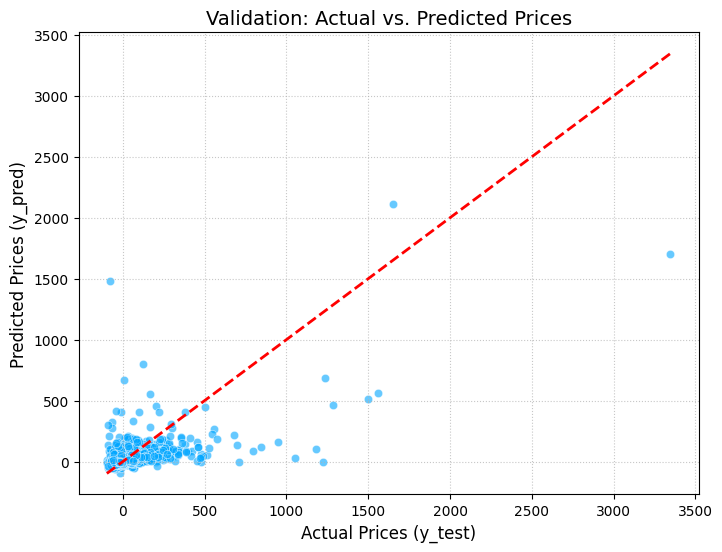

In [36]:
best_model=grid_searchLGB.best_estimator_
y_pred=best_model.predict(input_test)

test_r2=r2_score(target_test,y_pred)
test_mse=mean_squared_error(target_test,y_pred)
test_mae=mean_absolute_error(target_test,y_pred)
test_rmse=np.sqrt(mean_squared_error(target_test,y_pred))

print("R2 Score",test_r2)
print("MSE",test_mse)
print("MAE",test_mae)
print("RMSE",test_rmse)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=target_test, y=y_pred, alpha=0.6, color='#00a6ff')

min_val = min(target_test.min(), y_pred.min())
max_val = max(target_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title('Validation: Actual vs. Predicted Prices', fontsize=14)
plt.xlabel('Actual Prices (y_test)', fontsize=12)
plt.ylabel('Predicted Prices (y_pred)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [37]:
from google.colab import files

kaggle_test = test

test_ids = kaggle_test['id']

kaggle_predictions = best_model.predict(kaggle_test)

submission_df = pd.DataFrame({
    'id': test_ids,
    'return_pct': kaggle_predictions
})

submission_file = 'Stock_submission_LGB.csv'
submission_df.to_csv(submission_file, index=False)

print("Submission file created successfully!")
files.download(submission_file)


Submission file created successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>